Author: Nicolas Legrand <nicolas.legrand@cas.au.dk>

In [1]:
import sys
from pathlib import Path

# Add the parent directory to sys.path
parent_path = Path().resolve().parent
if str(parent_path) not in sys.path:
    sys.path.append(str(parent_path))

In [2]:
import numpy as np
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import pytensor.tensor as pt
import pymc as pm
from scipy.stats import norm
from pathlib import Path
from models.utils import cumulative_normal

plt.rcParams["figure.constrained_layout.use"] = True

In [39]:
standard_model_path = Path.cwd().parent.parent / "results" / "standard_model_summary.csv"
standard_model_df = pd.read_csv(standard_model_path, low_memory=False)
standard_model_df = standard_model_df[standard_model_df.session == 2]

cardiac_believing_path = Path.cwd().parent.parent / "results" / "cardiac_believing_summary.csv"
cardiac_believing_df = pd.read_csv(cardiac_believing_path, low_memory=False)
cardiac_believing_df = cardiac_believing_df[cardiac_believing_df.session == 2]

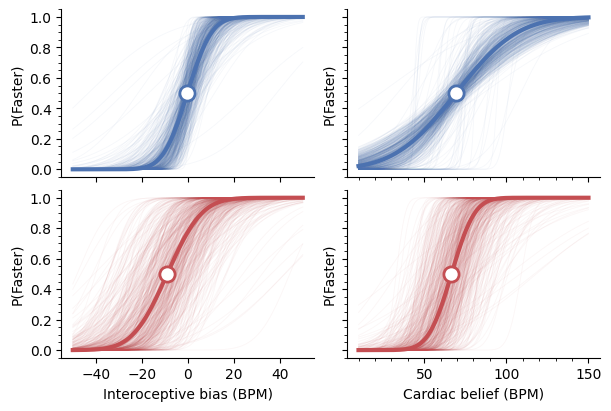

In [110]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(6, 4), sharex="col", sharey=True)

# Standard psychophysics --------------------
x_standard = np.linspace(-50, 50, 500)
for participant_id in standard_model_df.participant_id.to_list():
    extero_threshold = standard_model_df[standard_model_df.participant_id == participant_id].extero_threshold.values[0]
    intero_threshold = standard_model_df[standard_model_df.participant_id == participant_id].intero_threshold.values[0]
    intero_slope = standard_model_df[standard_model_df.participant_id == participant_id].intero_slope.values[0]
    extero_slope = standard_model_df[standard_model_df.participant_id == participant_id].extero_slope.values[0]

    axs[0, 0].plot(
        x_standard, 
        (norm.cdf(x_standard, loc=extero_threshold, scale=extero_slope)), 
        '-', alpha=.05, linewidth=.6, color='#4c72b0'
    )

    axs[1, 0].plot(
        x_standard, 
        (norm.cdf(x_standard, loc=intero_threshold, scale=intero_slope)), 
        '-', alpha=.05, linewidth=.6, color='#c44e52'
    )

axs[0, 0].plot(
    x_standard, 
    (norm.cdf(x_standard, loc=standard_model_df.extero_threshold.mean(), scale=standard_model_df.extero_slope.mean())), 
    '-', color='#4c72b0', linewidth=3.0
)
axs[0, 0].scatter(x=standard_model_df.extero_threshold.mean(), y=.5, color='w', edgecolors="#4c72b0", zorder=10, s=120, linewidths=2)

axs[1, 0].plot(
    x_standard, 
    (norm.cdf(x_standard, loc=standard_model_df.intero_threshold.mean(), scale=standard_model_df.intero_slope.mean())), 
    '-', color='#c44e52', linewidth=3.0
)
axs[1, 0].scatter(x=standard_model_df.intero_threshold.mean(), y=.5, color='w', edgecolors="#c44e52", zorder=10, s=120, linewidths=2)


# Cardiac believing --------------------
x_believing = np.linspace(10, 150, 500)
for participant_id in cardiac_believing_df.participant_id.to_list():
    extero_mean = cardiac_believing_df[cardiac_believing_df.participant_id == participant_id].extero_mean.values[0]
    intero_mean = cardiac_believing_df[cardiac_believing_df.participant_id == participant_id].intero_mean.values[0]
    intero_std = cardiac_believing_df[cardiac_believing_df.participant_id == participant_id].intero_std.values[0]
    extero_std = cardiac_believing_df[cardiac_believing_df.participant_id == participant_id].extero_std.values[0]

    axs[0, 1].plot(
        x_believing, 
        (norm.cdf(x_believing, loc=extero_mean, scale=extero_std)), 
        '-', alpha=.05, linewidth=.6, color='#4c72b0'
    )

    axs[1, 1].plot(
        x_believing, 
        (norm.cdf(x_believing, loc=intero_mean, scale=intero_std)), 
        '-', alpha=.05, linewidth=.6, color='#c44e52'
    )

axs[0, 1].plot(
    x_believing, 
    (norm.cdf(x_believing, loc=cardiac_believing_df.extero_mean.mean(), scale=cardiac_believing_df.extero_std.mean())), 
    '-', color='#4c72b0', linewidth=3.0
)
axs[0, 1].scatter(x=cardiac_believing_df.extero_mean.mean(), y=.5, color='w', edgecolors="#4c72b0", zorder=10, s=120, linewidths=2)

axs[1, 1].plot(
    x_believing, 
    (norm.cdf(x_believing, loc=cardiac_believing_df.intero_mean.mean(), scale=cardiac_believing_df.intero_std.mean())), 
    '-', color='#c44e52', linewidth=3.0
)
axs[1, 1].scatter(x=cardiac_believing_df.intero_mean.mean(), y=.5, color='w', edgecolors="#c44e52", zorder=10, s=120, linewidths=2)

axs[0, 1].minorticks_on()
axs[1, 1].minorticks_on()

axs[0, 0].set(ylabel="P(Faster)")
axs[0, 1].set(ylabel="P(Faster)")
axs[1, 0].set(xlabel="Interoceptive bias (BPM)", ylabel="P(Faster)")
axs[1, 1].set(xlabel="Cardiac belief (BPM)", ylabel="P(Faster)")

sns.despine()

plt.savefig(Path().cwd().parent.parent / "figures" / "figure_2_psychometrics.svg")

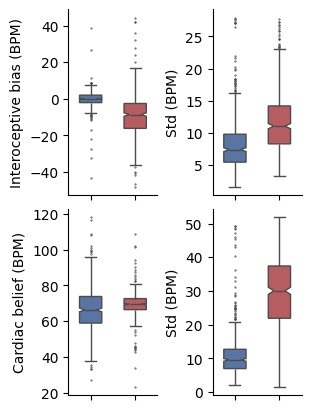

In [109]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(3, 4))

sns.boxplot(
    data=pd.melt(standard_model_df, id_vars=["participant_id"], value_vars=["extero_threshold", "intero_threshold"]), 
    x="variable", 
    y="value", 
    hue="variable", 
    ax=axs[0, 0],
    palette=["#4c72b0", "#c44e52"],
    notch=True,
    fliersize=.5,
    width=.5
)
axs[0, 0].set(ylabel="Interoceptive bias (BPM)", xlabel=None)
axs[0, 0].set_xticklabels([])

sns.boxplot(
    data=pd.melt(standard_model_df, id_vars=["participant_id"], value_vars=["extero_slope", "intero_slope"]), 
    x="variable", 
    y="value", 
    hue="variable", 
    ax=axs[0, 1],
    palette=["#4c72b0", "#c44e52"],
    notch=True,
    fliersize=.5,
    width=.5
)
axs[0, 1].set(ylabel="Std (BPM)", xlabel=None)
axs[0, 1].set_xticklabels([])

sns.boxplot(
    data=pd.melt(cardiac_believing_df, id_vars=["participant_id"], value_vars=["intero_mean", "extero_mean"]), 
    x="variable", 
    y="value", 
    hue="variable", 
    ax=axs[1, 0],
    palette=["#4c72b0", "#c44e52"],
    notch=True,
    fliersize=.5,
    width=.5
)
axs[1, 0].set(ylabel="Cardiac belief (BPM)", xlabel=None)
axs[1, 0].set_xticklabels([])

sns.boxplot(
    data=pd.melt(cardiac_believing_df, id_vars=["participant_id"], value_vars=["intero_std", "extero_std"]), 
    x="variable", 
    y="value", 
    hue="variable", 
    ax=axs[1, 1],
    palette=["#4c72b0", "#c44e52"],
    notch=True,
    fliersize=.5,
    width=.5
)
axs[1, 1].set(ylabel="Std (BPM)", xlabel=None)
axs[1, 1].set_xticklabels([])

sns.despine()

plt.savefig(Path().cwd().parent.parent / "figures" / "figure_2_boxplots.svg")